# Function 1 – Emotional Pattern Clustering

Groups children by their **emotional pattern** using two unsupervised models
(**K-Means** and **DBSCAN**), trained on the real Component 3 output
`educator_sessions.csv` (754 dialogue sessions, 40 children, 20 Jul – 27 Sep 2026).

Component 3 (Socratic Educator) sends one record per session with the child's
`emotional_state` (calm / defensive / distressed / unclear). Clustering needs one
row per **child**, so the sessions are first aggregated into six emotional-pattern
features per child. There are no "correct" groups to learn from, so the models are
checked with internal scores (silhouette, Davies–Bouldin), a stability test, and a
hold-out test on children the model never saw.

Pipeline: load → validate → build child features → scale → train K-Means (k = 2..8)
→ final K-Means + cluster names → stability check → hold-out check → train DBSCAN
→ compare models → emotion trend over time → save artifacts.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

SEED = 42

print("Libraries loaded successfully")
print("scikit-learn version:", sklearn.__version__)

Libraries loaded successfully
scikit-learn version: 1.6.1


## Step 1–2: Load and validate the dataset

The cleaning, feature and prediction code is written to **`emotional_pattern.py`** by
the cell before Step 3, so the notebook and the dashboard pipeline use exactly the
same code. Edit the code in that cell, not in the `.py` file (it is overwritten on
every run).

- **Colab:** upload `educator_sessions.csv` to `/content`.
- **Local / VS Code:** start Jupyter from this folder. The CSV is found next to the
  notebook or in a sibling `Function 1/` or `Function_1/` folder.

Open the CSV only in Colab / VS Code: re-saving it in Excel rewrites the
`True`/`False` values.

In [2]:
# Load the Component 3 output
from pathlib import Path

DATA_PATHS = [
    "/content/educator_sessions.csv",
    "/content/sample_data/educator_sessions.csv",
    "educator_sessions.csv",
    "../Function 1/educator_sessions.csv",
    "../Function_1/educator_sessions.csv",
]
DATA_PATH = next((p for p in DATA_PATHS if Path(p).is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"educator_sessions.csv not found in any of: {DATA_PATHS}")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully from", DATA_PATH)
print("Dataset shape:", df.shape)

# Preview first 5 records
display(df.head())

Dataset loaded successfully from /content/sample_data/educator_sessions.csv
Dataset shape: (754, 9)


,child_id,session_id,timestamp,risk_level,emotional_state,self_regulation_shown,escalation_flag,dialogue_turns,dialogue_summary
0,C001,S-000001,2026-08-20T16:08:00Z,moderate,distressed,False,False,2,2 turns; risk_category=violence
1,C001,S-000002,2026-07-31T16:14:00Z,low,defensive,False,False,2,2 turns; risk_category=explicit_visual
2,C001,S-000003,2026-09-27T18:14:00Z,moderate,defensive,False,False,2,2 turns; risk_category=cyberbullying
3,C001,S-000004,2026-08-09T20:27:00Z,low,distressed,False,False,2,2 turns; risk_category=self_harm_imagery
4,C001,S-000005,2026-08-02T15:24:00Z,moderate,defensive,False,False,3,3 turns; risk_category=grooming_language


In [3]:
# ==========================================
# STEP 2: BASIC DATASET VALIDATION
# ==========================================

print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n===== CHILDREN AND SESSIONS =====")
print("Unique children:", df["child_id"].nunique())
print("Unique sessions:", df["session_id"].nunique())
sessions_per_child = df.groupby("child_id").size()
print("Sessions per child: min", sessions_per_child.min(),
      "| mean", round(sessions_per_child.mean(), 1),
      "| max", sessions_per_child.max())

print("\n===== EMOTIONAL STATE COUNTS =====")
print(df["emotional_state"].value_counts())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   child_id               754 non-null    object
 1   session_id             754 non-null    object
 2   timestamp              754 non-null    object
 3   risk_level             754 non-null    object
 4   emotional_state        754 non-null    object
 5   self_regulation_shown  754 non-null    bool  
 6   escalation_flag        754 non-null    bool  
 7   dialogue_turns         754 non-null    int64 
 8   dialogue_summary       754 non-null    object
dtypes: bool(2), int64(1), object(6)
memory usage: 42.8+ KB

===== MISSING VALUES =====
child_id                 0
session_id               0
timestamp                0
risk_level               0
emotional_state          0
self_regulation_shown    0
escalation_flag          0
dialogue_turns           0

## Pipeline code: `emotional_pattern.py`

These functions are used by the notebook **and** by the parent dashboard pipeline:

| Function | What it does |
|---|---|
| `clean_sessions(df)` | Checks required columns, True/False values, emotion labels, `dialogue_turns` and unique `session_id`; converts types; sorts by child and time |
| `build_features(sessions)` | One row per child with the six emotional-pattern features |
| `load_artifacts()` | Loads the saved K-Means, scaler and metadata (cluster names from the JSON) |
| `predict_patterns(sessions)` | Assigns each child to a trained pattern |
| `run_emotional_pattern(csv_or_df)` | Full pipeline: validate → clean → features → pattern |

`%%writefile` saves the cell as `emotional_pattern.py` next to the notebook; the next
cell imports it. The dashboard only needs this file plus the saved `.pkl` / `.json`
files from Step 14.

In [4]:
%%writefile emotional_pattern.py
"""Function 1 - Emotional Pattern Clustering: reusable pipeline code.

Used by the notebook for training and by the dashboard pipeline for prediction,
so cleaning, features and prediction are defined in one place only.

    from emotional_pattern import run_emotional_pattern
    patterns = run_emotional_pattern("educator_sessions.csv")
"""

import json
from pathlib import Path

import joblib
import pandas as pd

EMOTIONS = ["calm", "defensive", "distressed", "unclear"]
FEATURES = [f"p_{e}" for e in EMOTIONS] + ["selfreg_rate", "mean_turns"]
REQUIRED_COLUMNS = ["child_id", "session_id", "timestamp", "emotional_state",
                    "self_regulation_shown", "dialogue_turns"]
BOOL_COLUMNS = ["self_regulation_shown", "escalation_flag"]

ARTIFACT_DIR = Path(__file__).resolve().parent


def clean_sessions(df):
    """Validate and clean Component 3 session records.

    Raises ValueError instead of silently producing wrong features.
    """
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    sessions = df.copy()

    for col in [c for c in BOOL_COLUMNS if c in sessions.columns]:
        sessions[col] = (
            sessions[col].astype(str).str.strip().str.lower()
            .map({"true": True, "false": False})
        )
        if sessions[col].isna().any():
            raise ValueError(f"{col} has values that are not True/False")

    sessions["timestamp"] = pd.to_datetime(sessions["timestamp"], utc=True)
    sessions["emotional_state"] = sessions["emotional_state"].astype(str).str.strip().str.lower()

    unknown = set(sessions["emotional_state"]) - set(EMOTIONS)
    if unknown:
        raise ValueError(f"Unknown emotional_state values: {sorted(unknown)}")

    sessions["dialogue_turns"] = pd.to_numeric(sessions["dialogue_turns"], errors="raise")
    if (sessions["dialogue_turns"] < 1).any():
        raise ValueError("dialogue_turns must be at least 1")

    sessions = sessions.drop_duplicates()
    if sessions["session_id"].duplicated().any():
        raise ValueError("session_id is not unique after removing exact duplicates")

    return sessions.sort_values(["child_id", "timestamp"]).reset_index(drop=True)


def build_features(sessions):
    """Aggregate cleaned sessions into one row of emotional-pattern features per child."""
    g = sessions.groupby("child_id")

    X = pd.DataFrame({
        f"p_{e}": g["emotional_state"].apply(lambda x, e=e: (x == e).mean())
        for e in EMOTIONS
    })
    X["selfreg_rate"] = g["self_regulation_shown"].mean().astype(float)
    X["mean_turns"] = g["dialogue_turns"].mean()

    return X[FEATURES]


def load_artifacts(artifact_dir=ARTIFACT_DIR):
    """Load the trained model, scaler and metadata saved by the notebook."""
    artifact_dir = Path(artifact_dir)
    model = joblib.load(artifact_dir / "emotional_pattern_kmeans.pkl")
    scaler = joblib.load(artifact_dir / "emotional_pattern_scaler.pkl")
    with open(artifact_dir / "emotional_pattern_metadata.json") as f:
        metadata = json.load(f)

    # JSON stores the cluster ids as strings
    metadata["cluster_names"] = {int(c): n for c, n in metadata["cluster_names"].items()}
    return model, scaler, metadata


def predict_patterns(sessions, artifact_dir=ARTIFACT_DIR):
    """Assign each child in cleaned session data to a trained emotional pattern."""
    model, scaler, metadata = load_artifacts(artifact_dir)

    X = build_features(sessions)[metadata["features"]]
    labels = model.predict(scaler.transform(X))

    return pd.DataFrame({
        "sessions": sessions.groupby("child_id").size().loc[X.index].values,
        "cluster": labels,
        "pattern": [metadata["cluster_names"][c] for c in labels]
    }, index=X.index)


def run_emotional_pattern(data, artifact_dir=ARTIFACT_DIR):
    """Full pipeline: CSV path or DataFrame -> validate -> clean -> features -> patterns."""
    df = pd.read_csv(data) if isinstance(data, (str, Path)) else data
    return predict_patterns(clean_sessions(df), artifact_dir)


Writing emotional_pattern.py


## Step 3: Clean and validate the data

`clean_sessions()` from `emotional_pattern.py`:

- converts `self_regulation_shown` and `escalation_flag` from text `True`/`False` to
  real booleans, and **stops with an error** if any other value appears;
- converts `timestamp` to a date-time (UTC) so sessions can be ordered and grouped
  into time windows later (Step 13);
- standardises emotion labels to lower case and **stops with an error** if a label
  other than calm / defensive / distressed / unclear appears (an unknown label would
  otherwise make the four emotion shares stop adding up to 1 without any warning);
- removes exact duplicates and checks that every `session_id` is unique;
- sorts records by child and time.

In [5]:
# ==========================================
# STEP 3: CLEAN AND VALIDATE THE DATA
# ==========================================

import importlib
import emotional_pattern
importlib.reload(emotional_pattern)  # pick up edits when the notebook is re-run

from emotional_pattern import (
    EMOTIONS, FEATURES, clean_sessions, build_features, run_emotional_pattern
)

sessions = clean_sessions(df)

print("Data cleaned and validated successfully")
print("Clean shape:", sessions.shape)
print("Emotion labels:", sorted(sessions["emotional_state"].unique()))
print("Unique session IDs:", sessions["session_id"].is_unique)
print("Date range:", sessions["timestamp"].min(), "->", sessions["timestamp"].max())
print("\nself_regulation_shown:")
print(sessions["self_regulation_shown"].value_counts())

# escalation_flag carries no information of its own: it is set exactly when risk_level is high
print("\nescalation_flag == (risk_level == 'high') for every session:",
      (sessions["escalation_flag"] == (sessions["risk_level"] == "high")).all())

Data cleaned and validated successfully
Clean shape: (754, 9)
Emotion labels: ['calm', 'defensive', 'distressed', 'unclear']
Unique session IDs: True
Date range: 2026-07-20 16:19:00+00:00 -> 2026-09-27 21:00:00+00:00

self_regulation_shown:
self_regulation_shown
False    691
True      63
Name: count, dtype: int64

escalation_flag == (risk_level == 'high') for every session: True


## Step 4: Exploratory check

Before modelling, check that each child has enough repeated sessions to form a
pattern, and how the emotion labels are distributed overall.

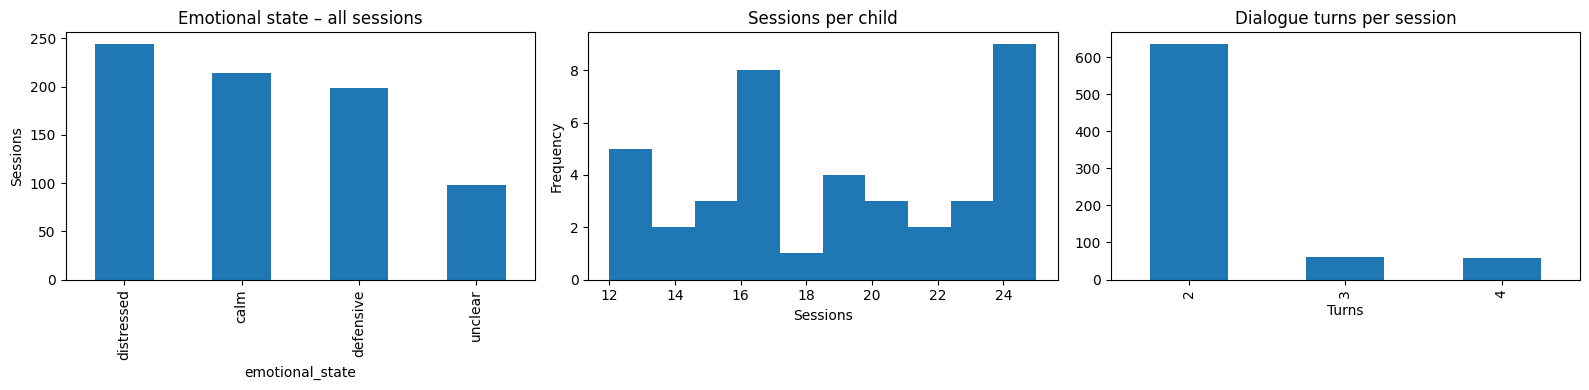

In [6]:
# ==========================================
# STEP 4: EXPLORATORY CHECK
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sessions["emotional_state"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Emotional state – all sessions")
axes[0].set_ylabel("Sessions")

sessions.groupby("child_id").size().plot(kind="hist", bins=10, ax=axes[1])
axes[1].set_title("Sessions per child")
axes[1].set_xlabel("Sessions")

sessions["dialogue_turns"].value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Dialogue turns per session")
axes[2].set_xlabel("Turns")

plt.tight_layout()
plt.show()

## Step 5: Build emotional-pattern features (one row per child)

Only **child-level emotional signals** are used:

| Feature | Meaning |
|---|---|
| `p_calm`, `p_defensive`, `p_distressed`, `p_unclear` | Share of the child's sessions with each emotional state |
| `selfreg_rate` | Share of sessions where the child stated their own safer alternative |
| `mean_turns` | Average dialogue turns (higher when the educator needs more turns to get an answer) |

`risk_level`, `escalation_flag` and `timestamp` are **excluded** – Component 3's
dataset card states they are random per session, so they say nothing about the
child's emotional pattern.

**Note:** the CSV has no numeric `emotion_score`, only an emotion label per session,
so label shares are used instead of an average score.

`build_features()` is defined in `emotional_pattern.py`.

In [7]:
# ==========================================
# STEP 5: BUILD CHILD-LEVEL FEATURES
# ==========================================

X = build_features(sessions)

print("Feature table created successfully")
print("Shape:", X.shape)
print("Missing values:", X.isnull().sum().sum())
print("Emotion shares add up to 1:",
      np.allclose(X[[f"p_{e}" for e in EMOTIONS]].sum(axis=1), 1))

display(X.head(10).round(3))
display(X.describe().round(3))

Feature table created successfully
Shape: (40, 6)
Missing values: 0
Emotion shares add up to 1: True


,p_calm,p_defensive,p_distressed,p_unclear,selfreg_rate,mean_turns
child_id,,,,,,
C001,0.083,0.750,0.167,0.000,0.083,2.167
C002,0.739,0.000,0.130,0.130,0.435,2.087
C003,0.174,0.739,0.043,0.043,0.043,2.217
C004,0.583,0.167,0.167,0.083,0.250,2.042
C005,0.133,0.200,0.000,0.667,0.000,2.733
C006,0.042,0.167,0.750,0.042,0.042,2.042
C007,0.600,0.160,0.200,0.040,0.040,2.080
C008,0.692,0.077,0.154,0.077,0.462,2.077
C009,0.071,0.071,0.000,0.857,0.071,2.857


,p_calm,p_defensive,p_distressed,p_unclear,selfreg_rate,mean_turns
count,40.000,40.000,40.000,40.000,40.000,40.000
mean,0.279,0.275,0.319,0.128,0.085,2.229
std,0.261,0.284,0.310,0.203,0.119,0.296
min,0.000,0.000,0.000,0.000,0.000,2.000
25%,0.083,0.077,0.125,0.000,0.000,2.062
50%,0.159,0.147,0.167,0.049,0.048,2.125
75%,0.562,0.586,0.448,0.130,0.089,2.223
max,0.773,0.789,0.952,0.857,0.462,3.105


### Check: do `selfreg_rate` and `mean_turns` add new information?

If self-regulation or extra dialogue turns happen almost only with one emotion
label, those features repeat that label, and that emotion counts roughly twice in
the distance calculation.

In [8]:
print("Self-regulation shown, by emotional state (share of sessions):")
display(pd.crosstab(sessions["emotional_state"], sessions["self_regulation_shown"],
                    normalize="columns").round(2))

print("Dialogue turns, by emotional state (share of sessions):")
display(pd.crosstab(sessions["emotional_state"], sessions["dialogue_turns"],
                    normalize="columns").round(2))

print("Correlation between child-level features:")
display(X.corr().round(2))

Self-regulation shown, by emotional state (share of sessions):


self_regulation_shown,False,True
emotional_state,,
calm,0.22,0.94
defensive,0.29,0.00
distressed,0.35,0.06
unclear,0.14,0.00


Dialogue turns, by emotional state (share of sessions):


dialogue_turns,2,3,4
emotional_state,,,
calm,0.33,0.02,0.02
defensive,0.26,0.49,0.10
distressed,0.35,0.20,0.19
unclear,0.06,0.30,0.69


Correlation between child-level features:


,p_calm,p_defensive,p_distressed,p_unclear,selfreg_rate,mean_turns
p_calm,1.00,-0.33,-0.42,-0.17,0.75,-0.28
p_defensive,-0.33,1.00,-0.49,-0.23,-0.32,-0.10
p_distressed,-0.42,-0.49,1.00,-0.30,-0.28,-0.25
p_unclear,-0.17,-0.23,-0.30,1.00,-0.08,0.88
selfreg_rate,0.75,-0.32,-0.28,-0.08,1.00,-0.21
mean_turns,-0.28,-0.10,-0.25,0.88,-0.21,1.00


**Result:** `selfreg_rate` and `mean_turns` partly repeat the emotion labels:
94 % of self-regulation sessions are **calm** and 69 % of 4-turn sessions are
**unclear**; at child level `selfreg_rate` correlates 0.75 with `p_calm` and
`mean_turns` correlates 0.88 with `p_unclear`. The features are kept because they describe real behaviour, but the
calm and withdrawn groups are partly separated twice, which helps explain the very
high silhouette and stability scores. This is listed in the Limitations.

## Step 6: Feature scaling

`mean_turns` is around 2–3 while the shares are between 0 and 1. Both K-Means and
DBSCAN use distances, so without scaling `mean_turns` would dominate.
`StandardScaler` gives every feature mean 0 and standard deviation 1.

There is no train/test split here: clustering has no labels, so the models are
trained on all 40 children. Generalisation is tested separately in Step 10
(hold-out check).

In [9]:
# ==========================================
# STEP 6: FEATURE SCALING
# ==========================================

scaler = StandardScaler()

# Fit the scaler (learns mean and std of each feature)
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully")
print("Scaled shape:", X_scaled.shape)

print("\nMean of scaled features:")
print(np.round(X_scaled.mean(axis=0), 2))

print("\nStandard deviation of scaled features:")
print(np.round(X_scaled.std(axis=0), 2))

Feature scaling completed successfully
Scaled shape: (40, 6)

Mean of scaled features:
[ 0. -0.  0.  0. -0.  0.]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1.]


## Step 7: Train K-Means for k = 2 to 8

One K-Means model is trained for each k. `n_init=10` means each model is trained
10 times from different starting centres and the best run is kept.

Scores used to choose k:
- **Inertia** – for the elbow chart (look for the bend).
- **Silhouette** (higher is better, target > 0.5) – main score.
- **Davies–Bouldin** (lower is better) and **Calinski–Harabasz** (higher is better)
  – supporting scores.
- **Smallest cluster** – avoids groups that are too small to explain.

In [10]:
# ==========================================
# STEP 7: TRAIN K-MEANS FOR k = 2..8
# ==========================================

k_values = range(2, 9)
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=SEED
    ).fit(X_scaled)

    kmeans_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, model.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, model.labels_),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, model.labels_),
        "Smallest cluster": int(np.bincount(model.labels_).min())
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

print("===== K-MEANS TRAINING RESULTS =====")
display(kmeans_results_df.round(3))

best_k = int(kmeans_results_df.loc[kmeans_results_df["Silhouette"].idxmax(), "k"])
print("Best k by silhouette:", best_k)

===== K-MEANS TRAINING RESULTS =====


,k,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Smallest cluster
0,2,163.929,0.416,0.812,17.634,6
1,3,93.050,0.469,0.873,29.216,6
2,4,35.938,0.643,0.521,68.137,6
3,5,23.923,0.629,0.518,79.033,3
4,6,19.838,0.592,0.623,75.467,2
5,7,17.153,0.537,0.791,71.454,3
6,8,14.771,0.436,0.857,69.707,2


Best k by silhouette: 4


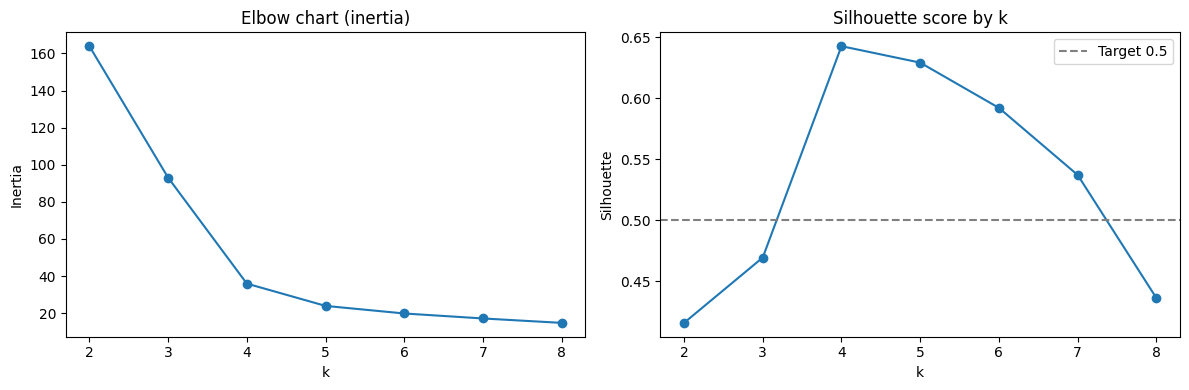

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(kmeans_results_df["k"], kmeans_results_df["Inertia"], "o-")
axes[0].set_title("Elbow chart (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_results_df["k"], kmeans_results_df["Silhouette"], "o-")
axes[1].axhline(0.5, color="grey", linestyle="--", label="Target 0.5")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

**Result:** k = 4 has the highest silhouette (**0.643**, above the 0.5 target), and
the elbow bends sharply at 4 (inertia 93 → 36, then only 36 → 24). k = 5 has a
marginally better Davies–Bouldin score (0.518 vs 0.521) but creates a cluster of
only 3 children, so **k = 4** is chosen.

## Step 8: Train the final K-Means model and name the clusters

The final model is trained with the chosen k. The cluster centres are converted
back to the original scale (`inverse_transform`) so they can be read, and each
cluster is named after its strongest emotion. Names are given **after** reading
the real centres. PCA is used only to draw the clusters in 2D – it is not the model.

In [11]:
# ==========================================
# STEP 8: TRAIN FINAL K-MEANS
# ==========================================

final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    max_iter=300,
    random_state=SEED
).fit(X_scaled)

print("Final K-Means trained successfully")
print("Converged in", final_kmeans.n_iter_, "iterations")
print("Inertia:", round(final_kmeans.inertia_, 3))

# Cluster centres in original units
centres = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=FEATURES
)
centres["Children"] = np.bincount(final_kmeans.labels_)

# Name each cluster after its strongest emotion
PATTERN_NAMES = {
    "calm": "Calm / reflective",
    "defensive": "Defensive",
    "distressed": "Distressed",
    "unclear": "Withdrawn / unclear"
}

cluster_names = {
    c: PATTERN_NAMES[centres.loc[c, [f"p_{e}" for e in EMOTIONS]].idxmax()[2:]]
    for c in centres.index
}
centres["Pattern"] = centres.index.map(cluster_names)

# Two clusters with the same strongest emotion would get the same name and
# break the severity order used in Step 13
assert len(set(cluster_names.values())) == best_k, \
    f"Cluster names are not unique: {cluster_names}"

print("\n===== FINAL CLUSTER CENTRES =====")
display(centres.round(3))

X_result = X.copy()
X_result["cluster"] = final_kmeans.labels_
X_result["pattern"] = X_result["cluster"].map(cluster_names)

Final K-Means trained successfully
Converged in 2 iterations
Inertia: 35.938

===== FINAL CLUSTER CENTRES =====


,p_calm,p_defensive,p_distressed,p_unclear,selfreg_rate,mean_turns,Children,Pattern
0,0.087,0.054,0.830,0.029,0.028,2.081,10,Distressed
1,0.656,0.119,0.156,0.069,0.218,2.090,12,Calm / reflective
2,0.133,0.688,0.129,0.050,0.022,2.164,12,Defensive
3,0.133,0.128,0.172,0.567,0.042,2.882,6,Withdrawn / unclear


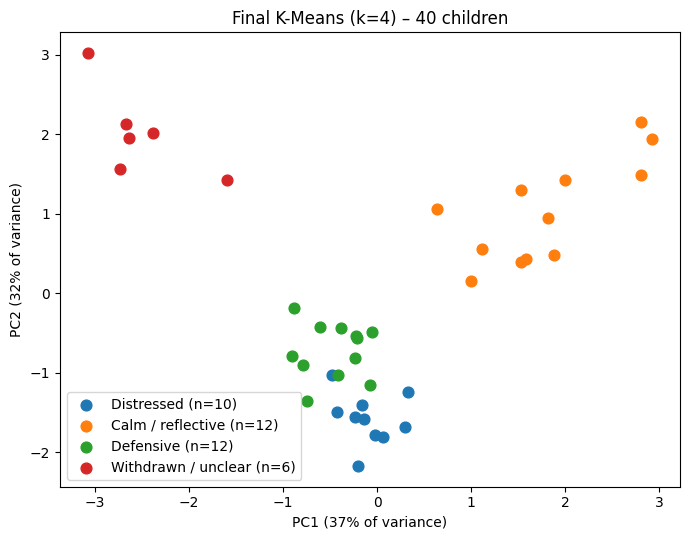

In [12]:
# 2D picture of the clusters (PCA is for visualisation only)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5.5))

for c in range(best_k):
    mask = final_kmeans.labels_ == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=60,
                label=f"{cluster_names[c]} (n={mask.sum()})")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
plt.title(f"Final K-Means (k={best_k}) – 40 children")
plt.legend()
plt.tight_layout()
plt.show()

**Result:** four clearly different groups – **Distressed** (10 children, 83 %
distressed sessions), **Calm / reflective** (12, 66 % calm, highest self-regulation
at 22 %), **Defensive** (12, 69 % defensive) and **Withdrawn / unclear** (6, 57 %
unclear, most dialogue turns at 2.88).

## Step 8b: Does the result depend on the two overlapping features?

Step 5 showed that `selfreg_rate` and `mean_turns` partly repeat the emotion shares.
To check that the groups do not depend on them, K-Means is retrained on the **four
emotion shares only** and compared with the final 6-feature model.

In [13]:
# ==========================================
# STEP 8B: 4-FEATURE ABLATION
# ==========================================

share_features = [f"p_{e}" for e in EMOTIONS]
X_shares_scaled = StandardScaler().fit_transform(X[share_features])
shares_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit(X_shares_scaled)

ablation_silhouette = silhouette_score(X_shares_scaled, shares_kmeans.labels_)
ablation_ari = adjusted_rand_score(final_kmeans.labels_, shares_kmeans.labels_)

print("4-feature model (emotion shares only)")
print("Silhouette:", round(ablation_silhouette, 3), "| 6-feature model:",
      round(silhouette_score(X_scaled, final_kmeans.labels_), 3))
print("ARI vs 6-feature final model:", round(ablation_ari, 3))

4-feature model (emotion shares only)
Silhouette: 0.733 | 6-feature model: 0.643
ARI vs 6-feature final model: 1.0


**Result:** the emotion shares alone give **the same 4 groups** (ARI 1.000) with a
higher silhouette (0.733 vs 0.643). The groups therefore do not depend on
`selfreg_rate` and `mean_turns`; they are kept because they make the groups easier
to describe (self-regulation for Calm, longer dialogues for Withdrawn).

## Step 9: Stability check across random seeds

K-Means starts from random centres. To show the groups are not the result of one
lucky start, the final model is retrained with 10 different seeds and each result
is compared with the final model using the **Adjusted Rand Index (ARI)**:
1.0 = identical groups, 0 = no better than random.

In [14]:
# ==========================================
# STEP 9: STABILITY CHECK
# ==========================================

stability_rows = []

for seed in range(10):
    labels = KMeans(n_clusters=best_k, n_init=10, random_state=seed).fit_predict(X_scaled)
    stability_rows.append({
        "seed": seed,
        "ARI vs final model": adjusted_rand_score(final_kmeans.labels_, labels)
    })

stability_df = pd.DataFrame(stability_rows)

print("===== STABILITY OVER 10 SEEDS =====")
print("Mean ARI:", round(stability_df["ARI vs final model"].mean(), 3))
print("Min ARI :", round(stability_df["ARI vs final model"].min(), 3))

===== STABILITY OVER 10 SEEDS =====
Mean ARI: 1.0
Min ARI : 1.0


## Step 10: Hold-out check – children the model never saw

This is the clustering version of a train/test check. A new scaler and K-Means are
trained on children **C001–C020** only (the same development split Component 3
used), then the trained model **predicts** C021–C040. If the predicted groups match
the full model, the model generalises to new children.

In [15]:
# ==========================================
# STEP 10: HOLD-OUT CHECK
# ==========================================

train_ids = [c for c in X.index if int(c[1:]) <= 20]
test_ids = [c for c in X.index if int(c[1:]) > 20]

holdout_scaler = StandardScaler().fit(X.loc[train_ids])

holdout_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=SEED
).fit(holdout_scaler.transform(X.loc[train_ids]))

# Predict children the model has never seen
X_test_scaled = holdout_scaler.transform(X.loc[test_ids])
test_predictions = holdout_kmeans.predict(X_test_scaled)

full_model_labels = X_result.loc[test_ids, "cluster"].values

print("Hold-out check completed successfully")
print("Training children:", len(train_ids))
print("Unseen test children:", len(test_ids))
print("\nARI (hold-out predictions vs full model):",
      round(adjusted_rand_score(full_model_labels, test_predictions), 3))
print("Silhouette on unseen children:",
      round(silhouette_score(X_test_scaled, test_predictions), 3))

Hold-out check completed successfully
Training children: 20
Unseen test children: 20

ARI (hold-out predictions vs full model): 1.0
Silhouette on unseen children: 0.664


**Result:** stability ARI = **1.000** over all 10 seeds, and the model trained on
20 children puts every one of the 20 unseen children into the same group as the
full model (**ARI 1.000**, silhouette on unseen children 0.664).

## Step 11: Train DBSCAN

DBSCAN does not need k. It finds dense groups and marks isolated children as
**noise** (label −1). Two settings:

- **eps** – neighbourhood size, read from the bend in the k-distance chart.
- **min_samples** – kept at 3–5. The usual rule (2 × 6 features = 12) is too large
  for only 40 children.

Silhouette is calculated **without** noise points, so a setting that throws many
children away can look better than it is. Only settings with **≤ 10 % noise**
(at most 4 children) are accepted.

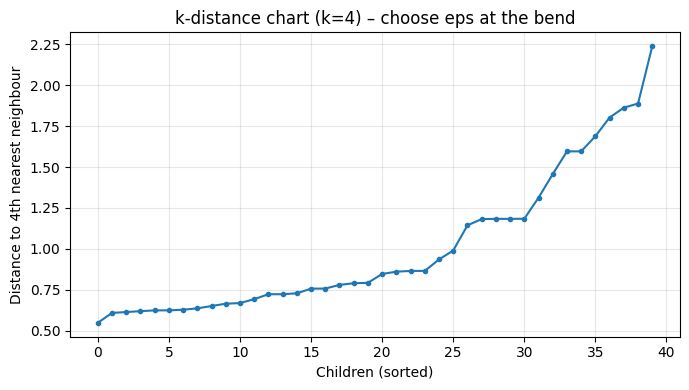

In [16]:
# ==========================================
# STEP 11A: K-DISTANCE CHART
# ==========================================

MIN_SAMPLES = 4

neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
k_distances = np.sort(neighbours.kneighbors(X_scaled)[0][:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances, "o-", markersize=3)
plt.title(f"k-distance chart (k={MIN_SAMPLES}) – choose eps at the bend")
plt.xlabel("Children (sorted)")
plt.ylabel("Distance to 4th nearest neighbour")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# STEP 11B: TRAIN DBSCAN OVER A PARAMETER GRID
# ==========================================

eps_values = [0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [3, 4, 5]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        kept = labels != -1

        if n_clusters >= 2 and kept.sum() > n_clusters:
            sil = silhouette_score(X_scaled[kept], labels[kept])
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Noise children": int((~kept).sum()),
            "Noise %": round(100 * (~kept).mean(), 1),
            "Silhouette (no noise)": sil
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

print("===== DBSCAN TRAINING RESULTS =====")
display(dbscan_results_df.round(3))

# Accept only settings that keep at least 90% of children
accepted = dbscan_results_df[
    (dbscan_results_df["Noise %"] <= 10) &
    dbscan_results_df["Silhouette (no noise)"].notna()
]

best_dbscan = accepted.sort_values("Silhouette (no noise)", ascending=False).iloc[0]
best_eps = float(best_dbscan["eps"])
best_min_samples = int(best_dbscan["min_samples"])

final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(X_scaled)

print("\nBest accepted DBSCAN: eps =", best_eps, "| min_samples =", best_min_samples)
print("Clusters:", int(best_dbscan["Clusters"]), "| Noise children:", int(best_dbscan["Noise children"]))

===== DBSCAN TRAINING RESULTS =====


,eps,min_samples,Clusters,Noise children,Noise %,Silhouette (no noise)
0,0.8,3,3,11,27.5,0.689
1,0.8,4,3,13,32.5,0.701
2,0.8,5,3,14,35.0,0.723
3,1.0,3,4,7,17.5,0.700
4,1.0,4,3,10,25.0,0.690
5,1.0,5,3,13,32.5,0.701
6,1.2,3,4,4,10.0,0.670
7,1.2,4,3,7,17.5,0.658
8,1.2,5,3,9,22.5,0.683
9,1.5,3,4,0,0.0,0.643



Best accepted DBSCAN: eps = 1.2 | min_samples = 3
Clusters: 4 | Noise children: 4


## Step 12: Compare K-Means vs DBSCAN

Both trained models are compared on separation (silhouette, Davies–Bouldin),
coverage (children left out as noise) and whether they can assign a **new** child
without retraining. ARI between the two models shows how much they agree.

In [18]:
# ==========================================
# STEP 12: COMPARE THE TWO MODELS
# ==========================================

db_labels = final_dbscan.labels_
db_kept = db_labels != -1

# DBSCAN with no children left out, for a like-for-like check:
# the zero-noise setting from the Step 11 grid with the best silhouette
no_noise_row = (
    dbscan_results_df[dbscan_results_df["Noise children"] == 0]
    .sort_values(["Silhouette (no noise)", "eps", "min_samples"],
                 ascending=[False, True, True])
    .iloc[0]
)
nn_eps = float(no_noise_row["eps"])
nn_min_samples = int(no_noise_row["min_samples"])
dbscan_no_noise = DBSCAN(eps=nn_eps, min_samples=nn_min_samples).fit(X_scaled)

comparison = pd.DataFrame([
    {
        "Model": f"K-Means (k={best_k})",
        "Clusters": best_k,
        "Children left out": 0,
        "Silhouette": silhouette_score(X_scaled, final_kmeans.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, final_kmeans.labels_),
        "Predicts new child": "Yes (.predict)",
        "ARI vs K-Means": 1.0
    },
    {
        "Model": f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})",
        "Clusters": int(best_dbscan["Clusters"]),
        "Children left out": int((~db_kept).sum()),
        "Silhouette": silhouette_score(X_scaled[db_kept], db_labels[db_kept]),
        "Davies-Bouldin": davies_bouldin_score(X_scaled[db_kept], db_labels[db_kept]),
        "Predicts new child": "No (must retrain)",
        "ARI vs K-Means": adjusted_rand_score(final_kmeans.labels_, db_labels)
    },
    {
        "Model": f"DBSCAN (eps={nn_eps}, min_samples={nn_min_samples})",
        "Clusters": len(set(dbscan_no_noise.labels_) - {-1}),
        "Children left out": int((dbscan_no_noise.labels_ == -1).sum()),
        "Silhouette": silhouette_score(X_scaled, dbscan_no_noise.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, dbscan_no_noise.labels_),
        "Predicts new child": "No (must retrain)",
        "ARI vs K-Means": adjusted_rand_score(final_kmeans.labels_, dbscan_no_noise.labels_)
    }
])

print("===== K-MEANS vs DBSCAN =====")
display(comparison.round(3))

===== K-MEANS vs DBSCAN =====


,Model,Clusters,Children left out,Silhouette,Davies-Bouldin,Predicts new child,ARI vs K-Means
0,K-Means (k=4),4,0,0.643,0.521,Yes (.predict),1.000
1,"DBSCAN (eps=1.2, min_samples=3)",4,4,0.670,0.474,No (must retrain),0.918
2,"DBSCAN (eps=1.5, min_samples=3)",4,0,0.643,0.521,No (must retrain),1.000


**Decision: K-Means with k = 4.**

| Reason | Evidence |
|---|---|
| Meets the target and covers every child | Silhouette 0.643 > 0.5, 0 children left out |
| DBSCAN's higher score is not like-for-like | 0.670 is calculated after leaving 4 children (10 %) unassigned – a parent cannot be told "your child fits no pattern" |
| Both methods find the same groups | DBSCAN with no noise (eps = 1.5) gives **exactly the same 4 groups** (ARI 1.000), so the groups are real, not a K-Means artefact |
| Usable in the pipeline | K-Means can `.predict()` a new child with the saved model; DBSCAN must be retrained each time |
| Reliable | Stable over 10 seeds and on unseen children (Steps 9–10) |

## Step 13: Emotion trend over time

The 10 weeks are split into **2-week windows** (5 windows). For each window, the
same six features are built from only that window's sessions, and the **already
trained** scaler + K-Means assign the child a pattern (no retraining).

**Minimum data per window:** a window with fewer than `MIN_SESSIONS = 3` sessions
is marked *Not enough data* instead of being given a pattern, because with one or
two sessions a single dialogue would decide the label. Windows with no sessions are
kept in the output (0 sessions) so every child has the same 5 windows on the
dashboard.

**Trend rule:** patterns are ordered by concern
(Calm 0 → Withdrawn 1 → Defensive 2 → Distressed 3). Withdrawn is ranked below
Defensive and Distressed because its sessions show low engagement rather than
active negative emotion; the order should be reviewed with the supervisor /
domain expert. Using only windows with enough data:

- **early** = average severity of the first two valid windows,
  **late** = average severity of the last two valid windows;
- **worsening** if late − early ≥ 1 (at least one concern level higher),
  **improving** if late − early ≤ −1, otherwise **stable**;
- a child with fewer than 3 valid windows gets **not enough data**.

Averaging two windows at each end means one unusual window cannot flip the result
on its own.

In [19]:
# ==========================================
# STEP 13: EMOTION TREND (2-WEEK WINDOWS)
# ==========================================

SEVERITY = {
    "Calm / reflective": 0,
    "Withdrawn / unclear": 1,
    "Defensive": 2,
    "Distressed": 3
}
MIN_SESSIONS = 3      # minimum sessions for a window to get a pattern
MIN_VALID_WINDOWS = 3 # minimum valid windows to judge a trend
CHANGE_THRESHOLD = 1  # change in average severity that counts as a real change
WINDOW_DAYS = 14

start = sessions["timestamp"].min().normalize()
sessions["window"] = ((sessions["timestamp"] - start).dt.days // WINDOW_DAYS) + 1
all_windows = range(1, int(sessions["window"].max()) + 1)

# Pattern for every child-window that has enough sessions
window_patterns = {}
for window, part in sessions.groupby("window"):
    counts = part.groupby("child_id").size()
    enough = counts[counts >= MIN_SESSIONS].index
    if len(enough) == 0:
        continue
    window_features = build_features(part[part["child_id"].isin(enough)])
    window_labels = final_kmeans.predict(scaler.transform(window_features))
    for child_id, label in zip(window_features.index, window_labels):
        window_patterns[(child_id, int(window))] = cluster_names[label]

session_counts = sessions.groupby(["child_id", "window"]).size()

trend_rows = []
for child_id in X.index:
    for window in all_windows:
        n = int(session_counts.get((child_id, window), 0))
        pattern = window_patterns.get((child_id, window))
        if pattern is None:
            pattern = "No sessions" if n == 0 else "Not enough data"
        trend_rows.append({
            "child_id": child_id,
            "window": window,
            "window_start": (start + pd.Timedelta(days=WINDOW_DAYS * (window - 1))).date().isoformat(),
            "sessions": n,
            "reliable": n >= MIN_SESSIONS,
            "pattern": pattern,
            "severity": SEVERITY.get(pattern, np.nan)
        })

trend_df = pd.DataFrame(trend_rows)


def trend_status(severities):
    valid = severities.dropna()
    if len(valid) < MIN_VALID_WINDOWS:
        return "not enough data", np.nan
    change = valid.iloc[-2:].mean() - valid.iloc[:2].mean()
    if change >= CHANGE_THRESHOLD:
        return "worsening", change
    if change <= -CHANGE_THRESHOLD:
        return "improving", change
    return "stable", change


emotion_trend = {}
for child_id, t in trend_df.groupby("child_id"):
    status, change = trend_status(t["severity"])
    emotion_trend[child_id] = {
        "overall_pattern": X_result.loc[child_id, "pattern"],
        "trend": status,
        "worsening": status == "worsening",
        "severity_change": None if np.isnan(change) else round(float(change), 2),
        "windows": t[["window", "window_start", "sessions", "reliable", "pattern"]].to_dict("records")
    }

with open("emotion_trend.json", "w") as f:
    json.dump(emotion_trend, f, indent=2)

status_counts = pd.Series({c: v["trend"] for c, v in emotion_trend.items()}).value_counts()
worsening = [c for c, v in emotion_trend.items() if v["trend"] == "worsening"]
improving = [c for c, v in emotion_trend.items() if v["trend"] == "improving"]

print("Emotion trend created successfully")
print("Windows:", len(all_windows))
print("Child-windows with a pattern:", len(window_patterns), "of", len(trend_df))
print("Child-windows marked 'Not enough data':", int((trend_df["pattern"] == "Not enough data").sum()))
print("Child-windows with no sessions:", int((trend_df["pattern"] == "No sessions").sum()))
print("\nTrend status:")
print(status_counts.to_string())
print("\nWorsening:", worsening)
print("Improving:", improving)
print("\nExample (first child):")
print(json.dumps(emotion_trend[X.index[0]], indent=2))

Emotion trend created successfully
Windows: 5
Child-windows with a pattern: 148 of 200
Child-windows marked 'Not enough data': 48
Child-windows with no sessions: 4

Trend status:
stable             30
not enough data     4
improving           4
worsening           2

Worsening: ['C004', 'C012']
Improving: ['C003', 'C007', 'C010', 'C034']

Example (first child):
{
  "overall_pattern": "Defensive",
  "trend": "not enough data",
  "worsening": false,
  "severity_change": null,
  "windows": [
    {
      "window": 1,
      "window_start": "2026-07-20",
      "sessions": 3,
      "reliable": true,
      "pattern": "Defensive"
    },
    {
      "window": 2,
      "window_start": "2026-08-03",
      "sessions": 1,
      "reliable": false,
      "pattern": "Not enough data"
    },
    {
      "window": 3,
      "window_start": "2026-08-17",
      "sessions": 4,
      "reliable": true,
      "pattern": "Defensive"
    },
    {
      "window": 4,
      "window_start": "2026-08-31",
      "sessi

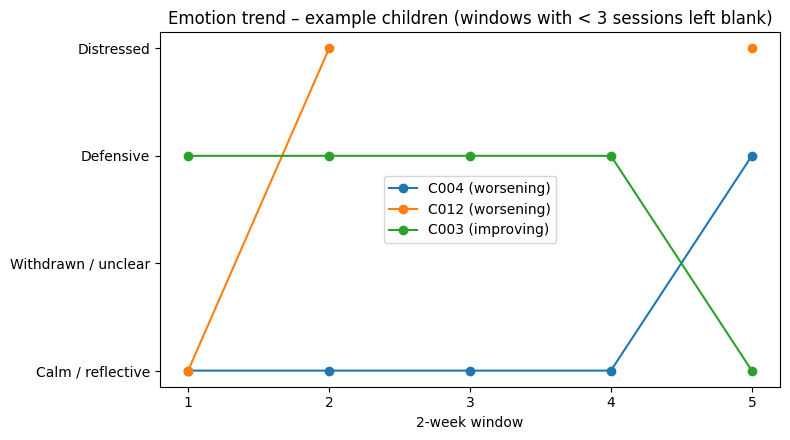

In [20]:
# Trend chart for 3 children (worsening children first); gaps = not enough data
example_children = (worsening + improving + [c for c in X.index if c not in worsening + improving])[:3]

plt.figure(figsize=(8, 4.5))

for child_id in example_children:
    t = trend_df[trend_df["child_id"] == child_id]
    plt.plot(t["window"], t["severity"], "o-",
             label=f"{child_id} ({emotion_trend[child_id]['trend']})")

plt.yticks(list(SEVERITY.values()), list(SEVERITY.keys()))
plt.xticks(list(all_windows))
plt.xlabel("2-week window")
plt.title(f"Emotion trend – example children (windows with < {MIN_SESSIONS} sessions left blank)")
plt.legend()
plt.tight_layout()
plt.show()

**Result:** 148 of 200 child-windows have enough sessions for a pattern; 48 are
marked *Not enough data* and 4 have no sessions. Trend: **30 stable, 4 improving
(C003, C007, C010, C034), 2 worsening (C004, C012)** and 4 with not enough data.

Compared with the first version (last window vs first window, any number of
sessions), C005, C025, C030 and C032 are **no longer flagged**: their change came
from a single window, in C032's case a window with only one session. C004
(Calm → Defensive) and C012 (Calm → Distressed) remain worsening under the stricter
rule. `emotion_trend.json` is the file the parent dashboard reads for
the emotion trend graph; `worsening` is kept as a true/false field for the existing
dashboard code.

## Step 14: Save model artifacts

The final K-Means model and the scaler are saved so the dashboard pipeline can
assign patterns to new session data **without retraining** (`scaler.transform` →
`kmeans.predict`). A metadata file records the scikit-learn version, settings,
cluster names and results, because pickled models may not load correctly under a
different scikit-learn version.

In [21]:
# ==========================================
# STEP 14: SAVE MODEL ARTIFACTS
# ==========================================

joblib.dump(final_kmeans, "emotional_pattern_kmeans.pkl")
joblib.dump(scaler, "emotional_pattern_scaler.pkl")
joblib.dump(FEATURES, "emotional_pattern_features.pkl")

X_result.to_csv("child_emotional_patterns.csv")

metadata = {
    "sklearn_version": sklearn.__version__,
    "trained_on": "educator_sessions.csv (Component 3)",
    "n_children": int(len(X)),
    "n_sessions": int(len(sessions)),
    "model": "KMeans",
    "params": {"n_clusters": best_k, "n_init": 10, "random_state": SEED},
    "features": FEATURES,
    "cluster_names": {int(c): n for c, n in cluster_names.items()},
    "severity_order": SEVERITY,
    "trend_settings": {"window_days": WINDOW_DAYS, "min_sessions": MIN_SESSIONS,
                       "min_valid_windows": MIN_VALID_WINDOWS,
                       "change_threshold": CHANGE_THRESHOLD},
    "results": {
        "silhouette": float(silhouette_score(X_scaled, final_kmeans.labels_)),
        "davies_bouldin": float(davies_bouldin_score(X_scaled, final_kmeans.labels_)),
        "stability_ari_mean": float(stability_df["ARI vs final model"].mean()),
        "holdout_ari": float(adjusted_rand_score(full_model_labels, test_predictions)),
        "dbscan_best": {"eps": best_eps, "min_samples": best_min_samples,
                        "noise_children": int((~db_kept).sum())},
        "trend_status_counts": {k: int(v) for k, v in status_counts.items()},
        "ablation_shares_only": {"silhouette": float(ablation_silhouette),
                                 "ari_vs_final": float(ablation_ari)}
    }
}

with open("emotional_pattern_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Reload test: the saved model must give the same answers
loaded_kmeans = joblib.load("emotional_pattern_kmeans.pkl")
loaded_scaler = joblib.load("emotional_pattern_scaler.pkl")
same = (loaded_kmeans.predict(loaded_scaler.transform(X)) == final_kmeans.labels_).all()

print("Final model artifacts saved successfully")
print("Reloaded model gives identical results:", same)

Final model artifacts saved successfully
Reloaded model gives identical results: True


## Step 15: Use the trained model on new data

`run_emotional_pattern()` in `emotional_pattern.py` is the reusable part for the
dashboard pipeline. It does **not** depend on anything defined in this notebook:
it validates and cleans the input (CSV path or DataFrame), builds the six
features, loads the saved scaler + K-Means + metadata (cluster names come from
`emotional_pattern_metadata.json`) and returns a pattern for each child.

Tests below: (1) the last 4 weeks of the real data, (2) a small mock file with the
same schema, (3) a mock file with an invalid emotion label, which must be rejected.

In [22]:
# ==========================================
# STEP 15: PREDICT PATTERNS FOR NEW DATA
# ==========================================

# Test 1: real data, last 4 weeks only
recent = df[pd.to_datetime(df["timestamp"], utc=True)
            >= pd.to_datetime(df["timestamp"], utc=True).max() - pd.Timedelta(days=28)]

print("Sessions in the last 4 weeks:", len(recent))
display(run_emotional_pattern(recent).head(10))

Sessions in the last 4 weeks: 295


,sessions,cluster,pattern
child_id,,,
C001,4,2,Defensive
C002,10,1,Calm / reflective
C003,8,2,Defensive
C004,8,2,Defensive
C005,7,3,Withdrawn / unclear
C006,5,0,Distressed
C007,11,1,Calm / reflective
C008,5,1,Calm / reflective
C009,5,3,Withdrawn / unclear


In [23]:
# Test 2: small mock file with the same schema as Component 3's output
mock = pd.DataFrame({
    "child_id": ["M001"] * 4 + ["M002"] * 4,
    "session_id": [f"M-{i:06d}" for i in range(1, 9)],
    "timestamp": pd.date_range("2026-10-01", periods=8, freq="D").strftime("%Y-%m-%dT%H:%M:%SZ"),
    "risk_level": ["low"] * 8,
    "emotional_state": ["calm", "calm", "calm", "defensive",
                        "unclear", "unclear", "unclear", "distressed"],
    "self_regulation_shown": ["True", "True", "False", "False",
                              "False", "False", "False", "False"],
    "escalation_flag": ["False"] * 8,
    "dialogue_turns": [2, 2, 2, 2, 4, 4, 3, 2],
    "dialogue_summary": ["mock"] * 8
})
mock.to_csv("mock_sessions.csv", index=False)

print("Mock file result:")
display(run_emotional_pattern("mock_sessions.csv"))

# Test 3: an invalid emotion label must be rejected, not silently scored
bad = mock.copy()
bad.loc[0, "emotional_state"] = "happy"
try:
    run_emotional_pattern(bad)
    print("ERROR: invalid label was accepted")
except ValueError as err:
    print("Invalid input rejected as expected:", err)

Mock file result:


,sessions,cluster,pattern
child_id,,,
M001,4,1,Calm / reflective
M002,4,3,Withdrawn / unclear


Invalid input rejected as expected: Unknown emotional_state values: ['happy']


In [24]:
# Optional: download the outputs from Colab
# from google.colab import files
# for name in ["emotional_pattern_kmeans.pkl", "emotional_pattern_scaler.pkl",
#              "emotional_pattern_features.pkl", "emotional_pattern_metadata.json",
#              "emotion_trend.json", "child_emotional_patterns.csv",
#              "emotional_pattern.py"]:
#     files.download(name)

## Limitations

| Limitation | How the notebook reduces it | What remains |
|---|---|---|
| Simulated children | Uses Component 3's real pipeline output, not hand-made data; excludes columns the generator randomises (Step 5) | Replies were written by a small LLM; results show the pipeline works, not how real children behave |
| Clean structure by design | Stability (Step 9), hold-out (Step 10) and agreement with DBSCAN (Step 12) | Each simulated child keeps one profile most of the time, so the perfect ARI partly reflects how the data was generated – expect messier clusters on real data |
| Small sample (40 children) | Several scores instead of silhouette alone (Step 7); smallest-cluster check | Silhouette values should be read with care |
| No numeric emotion score | Label shares per child used instead (Step 5) | Intensity of emotion within a label is not captured |
| Weakest label is `unclear` | Withdrawn group still separates clearly (Step 8) | Some withdrawn children who voice sadness are labelled distressed by Component 3 |
| Features partly repeat the labels | Checked in Step 5 (self-regulation is almost only calm; 4-turn sessions are mostly unclear) | Calm and withdrawn groups are partly separated twice, which inflates silhouette and ARI |
| Few sessions per time window | 2-week windows; windows with < 3 sessions get no pattern; trend compares the average of two windows at each end (Step 13) | Children with few sessions get *not enough data*; a valid window still rests on only 3–8 sessions |
| Severity order is a judgement | Order and reason stated in Step 13 | Withdrawn vs Defensive ranking should be confirmed by a domain expert |